# MHC class I: within-human similarity vs human-vs-viral

Question: **how similar are human self-peptides to each other, and how does that compare to the distance between human and viral peptides?**

Why it matters: TCRs are shaped by central tolerance against self, and viral epitopes that resemble self can drive cross-reactivity / molecular mimicry. The **within-human** distribution is the self-similarity background; the **human-vs-viral** distribution says how far viral 9-mers sit from that self space.

Scope (mirrors notebook 3): **MHC class I, positive, unmodified, 9-mers, standard 20 AA**.

Data:
- **Human self-peptides** come from the raw export (`IEDB/mhc_ligand_full.csv`), `species == "Homo sapiens"` — these are *excluded* from the pathogen working table, so we read them directly.
- **Viral peptides** come from the working table (`IEDB/iedb_human_pathogen_working_table_v2.csv`) restricted to viral species via `IEDB/species_virus_lookup.csv` (built in `2.5_species_virus_lookup.ipynb`).

Metrics: Levenshtein, Hamming, BLOSUM62-normalized (same definitions as notebook 3). We **sample pairs** rather than build a full matrix; identical-sequence pairs are kept (not excluded).

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import Levenshtein
from Bio.Align import substitution_matrices
from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(0)

# ---- config ----
PEPTIDE_LENGTH  = 9
POSITIVE_ONLY   = True
UNMODIFIED_ONLY = True
HEALTHY_ONLY    = True       # human self: keep only disease == "healthy" (drops tumor/neoantigen + unlabeled)
N_PAIRS         = 200_000    # sampled pairs per comparison

AA = set("ACDEFGHIKLMNPQRSTVWY")
RAW_CSV       = "IEDB/mhc_ligand_full.csv"
WORKING_TABLE = "IEDB/iedb_human_pathogen_working_table_v2.csv"
VIRUS_LOOKUP  = "IEDB/species_virus_lookup.csv"

## 1. Viral peptides (from the working table)

In [24]:
df = pd.read_csv(WORKING_TABLE, low_memory=False)
d = df[df["mhc_class"] == "I"].copy()
if POSITIVE_ONLY:   d = d[d["is_positive"]]
if UNMODIFIED_ONLY: d = d[~d["is_modified"]]
d = d[d["length"] == PEPTIDE_LENGTH]

vir = pd.read_csv(VIRUS_LOOKUP)
virus_species = set(vir.loc[vir["is_virus"], "species"])
d = d[d["species"].isin(virus_species)]
d = d[d["peptide"].map(lambda p: isinstance(p, str) and set(p) <= AA)]

viral_peptides = d["peptide"].unique()
print(f"viral {PEPTIDE_LENGTH}-mers: {len(d):,} records | {len(viral_peptides):,} unique peptides | {d['species'].nunique()} virus species")

viral 9-mers: 43,279 records | 14,970 unique peptides | 152 virus species


## 2. Human self-peptides (from the raw export)

Chunked scan of `mhc_ligand_full.csv` keeping host = human, linear peptides, `species == "Homo sapiens"`, MHC-I, positive, unmodified, and the focus length. (~5.6M rows — takes a minute.)

`species == "Homo sapiens"` is a *source-organism* label, so it mixes normal self with tumor-associated antigens and neoantigens. With `HEALTHY_ONLY = True` we keep only records whose `in vivo Disease` context is `"healthy"` (≈286k records), giving a cleaner germline-self set; this also drops the ~700k records with no disease label. Set `HEALTHY_ONLY = False` to use all human-source peptides (healthy + tumor).

In [25]:
# raw-export column indices (see 2_iedb_working_table.ipynb)
COLS = {10: "object_type", 11: "peptide", 14: "modifications",
        25: "species", 43: "host", 51: "disease", 94: "qualitative", 111: "mhc_class"}
USECOLS = sorted(COLS)
NAMES   = [COLS[i] for i in USECOLS]
HOST_HUMAN = "Homo sapiens (human)"

parts, n_rows = [], 0
reader = pd.read_csv(RAW_CSV, header=None, skiprows=2, usecols=USECOLS, names=NAMES,
                     dtype=str, chunksize=200_000, low_memory=False)
for ch in reader:
    n_rows += len(ch)
    ch = ch[(ch["host"] == HOST_HUMAN) &
            (ch["object_type"] == "Linear peptide") &
            (ch["species"] == "Homo sapiens") &
            (ch["mhc_class"] == "I")]
    if HEALTHY_ONLY:    ch = ch[ch["disease"] == "healthy"]   # drop tumor/neoantigen + unlabeled contexts
    if POSITIVE_ONLY:   ch = ch[ch["qualitative"].fillna("").str.startswith("Positive")]
    if UNMODIFIED_ONLY: ch = ch[ch["modifications"].isna()]
    ch = ch.dropna(subset=["peptide"])
    ch = ch[ch["peptide"].str.len() == PEPTIDE_LENGTH]
    if len(ch):
        parts.append(ch[["peptide"]])
    print(f"  scanned {n_rows:,} rows | kept {sum(len(p) for p in parts):,}", end="\r")

human = pd.concat(parts, ignore_index=True)
human_peptides = human.loc[human["peptide"].map(lambda p: set(p) <= AA), "peptide"].unique()
print(f"\nhuman self {PEPTIDE_LENGTH}-mers (healthy only: {HEALTHY_ONLY}): "
      f"{len(human):,} records | {len(human_peptides):,} unique peptides")

  scanned 5,571,576 rows | kept 286,327
human self 9-mers (healthy only: True): 286,327 records | 106,658 unique peptides


In [26]:
# peptides shared between the human self set and the viral set (exact 9-mer matches)
shared = set(human_peptides) & set(viral_peptides)
print(f"exact 9-mers present in BOTH human and viral sets: {len(shared):,}")
print(f"  ({len(shared) / len(viral_peptides) * 100:.2f}% of viral, {len(shared) / len(human_peptides) * 100:.2f}% of human)")

exact 9-mers present in BOTH human and viral sets: 2
  (0.01% of viral, 0.00% of human)


## 3. Distance metrics (same as notebook 3)

In [27]:
BL = substitution_matrices.load("BLOSUM62")
_self = {}

def _score(p, q):
    return sum(BL[a, b] for a, b in zip(p, q))

def selfscore(p):
    s = _self.get(p)
    if s is None:
        s = _self[p] = _score(p, p)
    return s

def lev(p, q):
    return Levenshtein.distance(p, q)

def hamming(p, q):
    return Levenshtein.hamming(p, q)

def blosum_dist(p, q):
    d = 1.0 - _score(p, q) / np.sqrt(selfscore(p) * selfscore(q))
    return max(d, 0.0)

METRICS_DICT = {"Levenshtein": lev, "Hamming": hamming, "BLOSUM62": blosum_dist}

def dists(pairs, metric_name):
    metric = METRICS_DICT[metric_name]
    return np.fromiter((metric(a, b) for a, b in pairs), dtype=float, count=len(pairs))

## 4. Sample pairs

- **within-human**: two peptides drawn independently from the human self set.
- **within-viral**: two peptides drawn independently from the viral set.
- **human-vs-viral**: one human peptide + one viral peptide.

Peptides are drawn uniformly over the *unique* sequences of each set; identical-sequence pairs are kept (not excluded).

In [28]:
def sample_within(peps, n):
    """n pairs drawn from one set (two independent draws; identical pairs kept)."""
    i = rng.integers(0, len(peps), size=n)
    j = rng.integers(0, len(peps), size=n)
    return list(zip(peps[i], peps[j]))

def sample_between(A, B, n):
    """n pairs with one peptide from set A and one from set B (identical pairs kept)."""
    i = rng.integers(0, len(A), size=n)
    j = rng.integers(0, len(B), size=n)
    return list(zip(A[i], B[j]))

within_pairs = sample_within(human_peptides, N_PAIRS)   # within-human
viral_pairs  = sample_within(viral_peptides, N_PAIRS)   # within-viral
cross_pairs  = sample_between(human_peptides, viral_peptides, N_PAIRS)  # human-vs-viral
print(f"within-human: {len(within_pairs):,} | within-viral: {len(viral_pairs):,} | human-vs-viral: {len(cross_pairs):,}")

within-human: 200,000 | within-viral: 200,000 | human-vs-viral: 200,000


In [29]:
rows = []
for label, pairs in [("within-human", within_pairs),
                     ("within-viral", viral_pairs),
                     ("human-vs-viral", cross_pairs)]:
    for mname in METRICS_DICT:
        for v in dists(pairs, mname):
            rows.append({"comparison": label, "metric": mname, "distance": v})
res = pd.DataFrame(rows)
res.groupby(["metric", "comparison"])["distance"].describe()[["mean", "50%", "std"]]

mean       50%       std
metric      comparison                                  
BLOSUM62    human-vs-viral  1.152955  1.164957  0.138499
            within-human    1.134117  1.147442  0.144747
            within-viral    1.154026  1.166714  0.139271
Hamming     human-vs-viral  8.371325  9.000000  0.765967
            within-human    8.298965  8.000000  0.808695
            within-viral    8.375265  9.000000  0.772919
Levenshtein human-vs-viral  8.240785  8.000000  0.807379
            within-human    8.159440  8.000000  0.845484
            within-viral    8.243240  8.000000  0.815866

In [30]:
# mean distance per comparison + Mann-Whitney: is each within-group SMALLER than human-vs-viral?
COMPARISONS = ["within-human", "within-viral", "human-vs-viral"]
summary = []
for mname in METRICS_DICT:
    s = res[res["metric"] == mname]
    g = {c: s[s["comparison"] == c]["distance"] for c in COMPARISONS}
    _, p_h = mannwhitneyu(g["within-human"], g["human-vs-viral"], alternative="less")
    _, p_v = mannwhitneyu(g["within-viral"], g["human-vs-viral"], alternative="less")
    summary.append({"metric": mname,
                    "mean_within_human": round(g["within-human"].mean(), 3),
                    "mean_within_viral": round(g["within-viral"].mean(), 3),
                    "mean_human_viral": round(g["human-vs-viral"].mean(), 3),
                    "p(human<cross)": f"{p_h:.1e}",
                    "p(viral<cross)": f"{p_v:.1e}"})
summary_df = pd.DataFrame(summary)
summary_df

,metric,mean_within_human,mean_within_viral,mean_human_viral,p(human<cross),p(viral<cross)
0,Levenshtein,8.159,8.243,8.241,5.3e-197,9.8e-01
1,Hamming,8.299,8.375,8.371,1.7e-166,1.0e+00
2,BLOSUM62,1.134,1.154,1.153,0.0e+00,1.0e+00


## 5. Distributions (one standalone figure per metric)

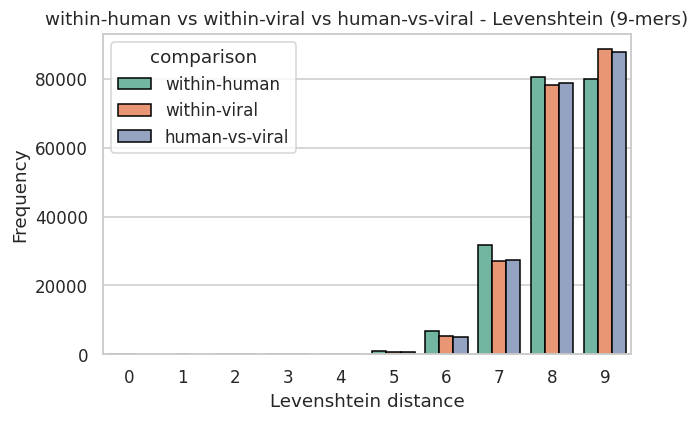

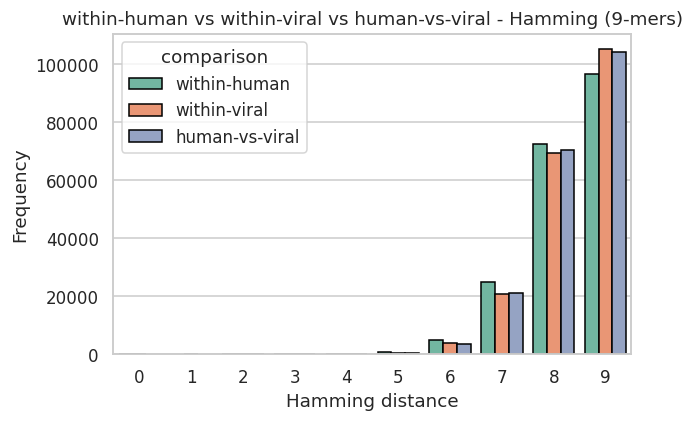

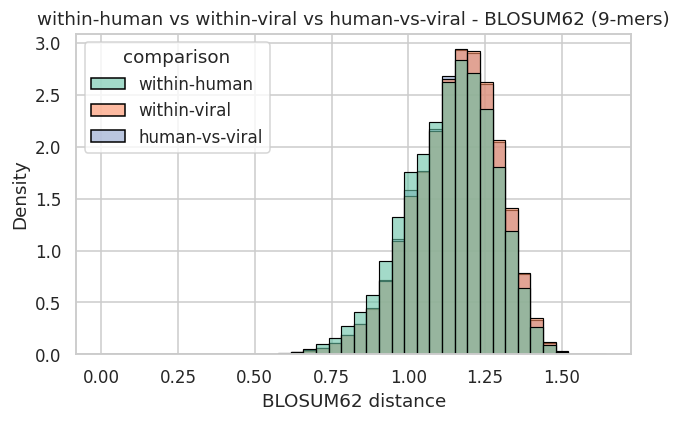

In [34]:
INTEGER_METRICS = ["Levenshtein", "Hamming"]
HUE_ORDER = ["within-human", "within-viral", "human-vs-viral"]

for mname in METRICS_DICT:
    sub = res[res["metric"] == mname]
    fig, ax = plt.subplots(figsize=(6, 4))
    if mname in INTEGER_METRICS:
        # integer distances -> side-by-side (dodged) frequency bars per comparison
        counts = (sub.assign(distance=sub["distance"].astype(int))
                     .groupby(["distance", "comparison"]).size()
                     .reset_index(name="frequency"))
        sns.barplot(data=counts, x="distance", y="frequency", hue="comparison",
                    hue_order=HUE_ORDER, palette="Set2", edgecolor="black", ax=ax)
        ax.set(ylabel="Frequency")
    else:
        # continuous -> overlaid (layered) density histogram
        sns.histplot(data=sub, x="distance", hue="comparison", hue_order=HUE_ORDER,
                     bins=40, stat="density", common_norm=False, palette="Set2",
                     edgecolor="black", alpha=0.6, ax=ax)
        ax.set(ylabel="Density")
    ax.set(title=f"within-human vs within-viral vs human-vs-viral - {mname} (9-mers)",
           xlabel=f"{mname} distance")
    plt.tight_layout()
    plt.show()

## 6. Notes / interpretation

- **within-human** and **within-viral** are the self-similarity backgrounds of each set; **human-vs-viral** is how far viral 9-mers sit from human self-peptides.
- If human-vs-viral overlaps the two within-group distributions, viral 9-mers are on average no closer to human self than peptides are to each other within either set — random 9-mer space dominates and there is little global mimicry signal. A human-vs-viral distribution shifted toward **lower** distances (more low-distance pairs) than the within-group backgrounds would point to viral peptides with self-resembling sequences (mimicry candidates).
- With `HEALTHY_ONLY = True` the human set is germline-self (disease == "healthy"); flip it off to add tumor / neoantigen peptides and compare.
- Caveats: distances are over *unique* 9-mers sampled uniformly (no allele/abundance weighting); the human set is MS-eluted-heavy while the viral set is binding/immunogenicity-heavy — a curation difference, not just biology.
- Next: condition on a shared HLA allele (compare *for the same presenting allele*) to remove the anchor-motif confound; and rank the closest human-viral pairs as explicit mimicry candidates.